In [1]:
import jax
jax.config.update("jax_enable_x64", True)

In [2]:
import numpy as np

In [3]:
from lenstronomy.LensModel.lens_model import LensModel
import lensinggw.constants.constants as const

In [4]:
import sys
import os
path = os.getcwd()
dir = '/home/manchun.yeung/microlensing/wolensing/wolensing'
sys.path.append(dir)

In [5]:
from plot.plot import plot_contour
import amplification_factor.amplification_factor as af

In [6]:
G = const.G  # gravitational constant [m^3 kg^-1 s^-2]
c = const.c  # speed of light [m/s]
M_sun = const.M_sun  # Solar mass [Kg]

coordinates in scaled units [x (radians) /thetaE_tot]

In [7]:
y0, y1 = 0.27, 0 # source position
l0, l1 = 0., 0 # lens position

zS = 2.0 # source redshift
zL = 0.5 # lens redshift

In [8]:
mL1 = 1*1e10

# convert to radians
from lensinggw.utils.utils import param_processing
thetaE = param_processing(zL, zS, mL1)

In [9]:
beta0, beta1 = y0 * thetaE*np.cos(np.radians(45)), y1 * thetaE*np.cos(np.radians(45))
eta10, eta11 = 0 * l0 * thetaE, 0 * l1 * thetaE

In [10]:
e1, e2 = 0, 0.3

In [11]:
lens_model_list = ['SIE']
kwargs_sie_1 = {'center_x': eta10, 'center_y': eta11, 'theta_E': thetaE, 'e1':e1, 'e2': e2}
kwargs_lens_list = [kwargs_sie_1]

In [12]:
lens_model_complete = LensModel(lens_model_list=lens_model_list)
T = lens_model_complete.fermat_potential
T0 = thetaE ** (-2) * T(0, 0, kwargs_lens_list, beta0, beta1)#[0]
Tscale = 4 * (1 + zL) * mL1 * M_sun * G / c ** 3
print('T0 = {}'.format(T0))
print('Tscale = {}'.format(Tscale))

T0 = 0.01595300796811316
Tscale = 295529.46153261454


In [13]:
kwargs_macro = {'source_pos_x': beta0,
                'source_pos_y': beta1,
                'theta_E': thetaE,
                'mu': 1
               }

In [14]:
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LensModel.lens_model import LensModel
lensmodel = LensModel(lens_model_list=lens_model_list)
solver = LensEquationSolver(
    lensModel = lensmodel
)
Img_ra, Img_dec = solver.image_position_stochastic(
    source_x = beta0,
    source_y = beta1,
    kwargs_lens = kwargs_lens_list,
    # min_distance = 1e-13,
    # solver='lenstronomy'
    search_window = 5*thetaE,
    # verbose=True,
    precision_limit=10**(-10),
    x_center = 0,
    y_center= 0
)

In [15]:
MacroImg_ra, MacroImg_dec = Img_ra, Img_dec

In [16]:
# from lensinggw.solver.images import microimages
# solver_kwargs = {'SearchWindowMacro': 10 * thetaE,
#                  # 'SearchWindow': 5 * thetaE2,
#                  'Optimization': True,
#                  # 'OverlapDist': 1e-18,
#                  # 'OverlapDistMacro': 1e-17,
#                  'OnlyMacro': True}
# MacroImg_ra, MacroImg_dec, pixel_width = microimages(source_pos_x=beta0,
#                                                      source_pos_y=beta1,
#                                                      lens_model_list=lens_model_list,
#                                                      kwargs_lens=kwargs_lens_list,
#                                                      **solver_kwargs)

from lensinggw.utils.utils import TimeDelay, magnifications, getMinMaxSaddle


Td = TimeDelay(MacroImg_ra, MacroImg_dec,
                beta0, beta1,
                zL, zS,
                lens_model_list, kwargs_lens_list)
Mus = magnifications(MacroImg_ra, MacroImg_dec, lens_model_list, kwargs_lens_list)

In [17]:
Td

array([     0.        ,  79644.63624047,  80155.63328302, 144611.32401447])

[ 1.05292829e-06 -4.76406916e-08  2.63515227e-07 -5.99317290e-07] [-5.79485007e-07  9.61022358e-07  9.23615592e-07 -3.78919800e-07] Img_pos


<Axes: >

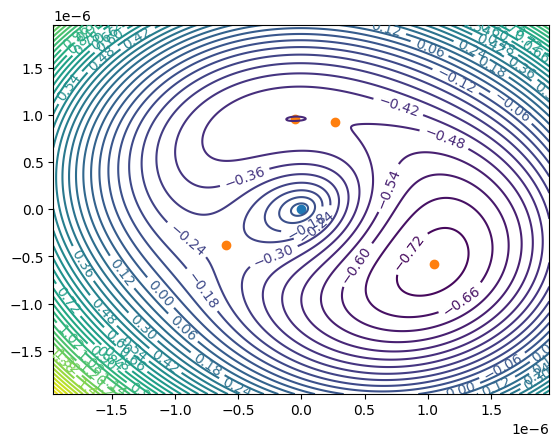

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plot_contour(ax, lens_model_list, eta10, eta11, 4*thetaE, kwargs_lens_list, beta0, beta1, MacroImg_ra, MacroImg_dec,
                    T0 = T0, Tfac = (thetaE)**(-2), micro=False)


In [19]:
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
# lens_model_list = ['POINT_MASS']
lens_model_complete = LensModel(lens_model_list=lens_model_list)
lensmodelext = LensModelExtensions(lens_model_complete)
ra_crit_list, dec_crit_list = lensmodelext.critical_curve_tiling(kwargs_lens_list, compute_window=10*thetaE, start_scale = thetaE/100, center_x=0, center_y=0)
ra_caustic_list, dec_caustic_list = lens_model_complete.ray_shooting(ra_crit_list, dec_crit_list, kwargs_lens_list)
macro_srcx, macro_srcy = lens_model_complete.ray_shooting(MacroImg_ra, MacroImg_dec, kwargs_lens_list)
# lens_srcx, lens_srcy = lens_model_complete.ray_shooting(eta20, eta21, kwargs_lens_list)

[ 1.05292829e-06 -4.76406916e-08  2.63515227e-07 -5.99317290e-07] [-5.79485007e-07  9.61022358e-07  9.23615592e-07 -3.78919800e-07] Img_pos


<Axes: >

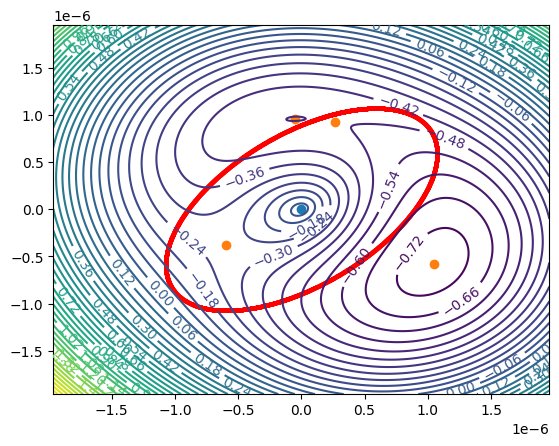

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plot_contour(ax, lens_model_list, eta10, eta11, 4*thetaE, kwargs_lens_list, beta0, beta1, MacroImg_ra, MacroImg_dec, crit_ra=ra_crit_list, crit_dec=dec_crit_list,
                    T0 = T0, Tfac = (thetaE)**(-2), micro=False)


In [21]:
MacroImg_ra, MacroImg_dec

(array([ 1.05292829e-06, -4.76406916e-08,  2.63515227e-07, -5.99317290e-07]),
 array([-5.79485007e-07,  9.61022358e-07,  9.23615592e-07, -3.78919800e-07]))

In [22]:
Td

array([     0.        ,  79644.63624047,  80155.63328302, 144611.32401447])

In [23]:
macro_srcx

array([1.8726874e-07, 1.8726874e-07, 1.8726874e-07, 1.8726874e-07])

In [24]:
macro_srcy

array([ 2.11758237e-22, -6.35274710e-22,  1.05879118e-22,  3.70576914e-22])

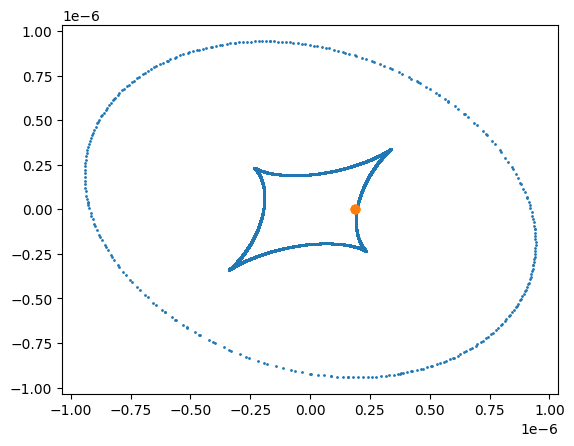

In [25]:
plt.scatter(ra_caustic_list, dec_caustic_list, s=1)
plt.scatter(macro_srcx, macro_srcy)
# plt.scatter(lens_srcx, lens_srcy)
# plt.scatter(circles_x, circles_y, s=0.5)

In [26]:
from lensmodels.trip_d import analytic_fold
source1 = np.array([macro_srcx[0], macro_srcy[0]])
fs = np.linspace(10, 2000, 1991)
zL = 0.5
mL = 1e10
img_1 = analytic_fold(lens_model_list, MacroImg_ra[2], MacroImg_dec[1], source1, kwargs_lens_list, zL, zS, mL, fs)
# img_2 = analytic_fold(lens_model_list, Img_ra[2], Img_dec[2], source2, kwargs_lens_list, zL, zS, mL, fs)

[0. 0. 0. 0.]
0.0 yyy
1.0 xx
0.0012495343174296115 1 / Mpc
4.049464937375886e-26


/home/manchun.yeung/microlensing/wolensing/wolensing/lensmodels/trip_d.py:38: RuntimeWarning: divide by zero encountered in divide
  ai, aip, bi, bip = Air(2**(1/3) * y2 * ws **(2/3) / abs(phi_yyy)**(1/3))
/home/manchun.yeung/microlensing/wolensing/wolensing/lensmodels/trip_d.py:40: RuntimeWarning: divide by zero encountered in divide
  function = ws**(1/6) / (abs(phi_xx) ** (1/2) * abs(phi_yyy)**(1/3)) * ai * np.exp(-1j * ws * y1**2/(2*phi_xx))


In [27]:
img_1

array([nan+nanj, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj])

In [ ]:
# Define the characteristic WindowSize
mL_ref = 10
thetaE_ref = param_processing(zL, zS, mL_ref)

kwargs_integrator = {'PixelNum': int(20000),          # Number of pixels on each side of the window
                     'PixelBlockMax': 2000,           # Dividing PixelNum into PixelBlock
                     'WindowSize': 210*thetaE_ref, 
                     'WindowCenterX': 0., 
                     'WindowCenterY': 0.,
                     'T0': T0,                        # Time delay of the reference point (WindowCenter)
                     'TimeStep': 1e-5/Tscale,         # integration step in time domain
                     'TimeMax': T0 + 5/Tscale,        # Upper bound of time integration
                     'TimeMin': T0 - .1/Tscale,       # Lower bound of time integration
                     'TimeLength': .13/Tscale,
                      'LastImageT': .02/Tscale,
                     'Tbuffer': 0,
                     'TExtend': 10/Tscale,            # Extend the time domain curve to desired time. In this example, it is extended to T0+10 seconds 
                     'Tscale': Tscale}                

start


Integrating...: 100%|██████████| 121/121 [01:15<00:00,  1.59it/s]


total time 10.129980000000002


<Figure size 432x288 with 0 Axes>

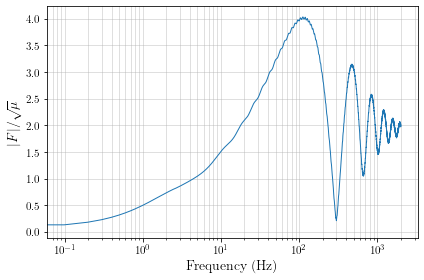

<AxesSubplot:xlabel='Frequency (Hz)', ylabel='$|F|/\\sqrt{\\mu}$'>

In [14]:
amplification = af.amplification_factor(lens_model_list=lens_model_list, kwargs_lens=kwargs_lens_list, kwargs_macro=kwargs_macro, **kwargs_integrator)
ts, F_tilde = amplification.integrator(gpu=True)
ws, Fws = amplification.fourier()
amplification.plot_freq()